## 1. Configuration


### 1.1 Imports


In [1]:
from __future__ import annotations

import os
import gc
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from dotenv import load_dotenv


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "code").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing both code/ and data/.")


### 1.2 Project Paths


In [2]:
PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / "../.." / ".env")
CODE_DIR = PROJECT_ROOT / "code"
DATASET_DIR = PROJECT_ROOT / "data" / "dataset" / "cleaned_dataset"
RESULTS_DIR = PROJECT_ROOT / "code" / "results" / "critiques"
CRITIQUES_PARQUET_DIR = RESULTS_DIR / "parquet"
MATCHING_ROOT_DIR = RESULTS_DIR / "matching"
MATCHING_ROOT_DIR.mkdir(parents=True, exist_ok=True)

if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))


### 1.3 Select LLM Run


In [34]:
LLM_RUNS = {
    "openai": {"provider": "openai", "model_short": "gpt5"},
    "anthropic": {"provider": "anthropic", "model_short": "claude4_7"},
    "google": {"provider": "google", "model_short": "gemini3_1pro"},
}

SELECTED_PROVIDER = "google"        # "openai" | "anthropic" | "google"
PROMPT_SETUP = "zero_shot"
TASK_SCOPE = "all_tasks"

RUN_CONFIG = LLM_RUNS[SELECTED_PROVIDER].copy()
LLM_NAME = RUN_CONFIG["model_short"]
RUN_LABEL = f"{PROMPT_SETUP}-{TASK_SCOPE}"

HUMAN_REFERENCE_FILE = DATASET_DIR / "human_comments_semantic_dedup.parquet"

def get_llm_input_path(model_short: str) -> Path:
    return CRITIQUES_PARQUET_DIR / f"critiques-{PROMPT_SETUP}-{TASK_SCOPE}-{model_short}-responses.parquet"


LLM_INPUT_PATH = get_llm_input_path(LLM_NAME)

print(f"Selected provider: {SELECTED_PROVIDER}")
print(f"LLM name: {LLM_NAME}")
print(f"Run label: {RUN_LABEL}")
print(f"LLM input path: {LLM_INPUT_PATH}")

Selected provider: google
LLM name: gemini3_1pro
Run label: zero_shot-all_tasks
LLM input path: /home/mkhalil/thesis/Project/code/results/critiques/parquet/critiques-zero_shot-all_tasks-gemini3_1pro-responses.parquet


### 1.4 Output Paths


In [35]:
MATCHING_OUTPUT_DIR = MATCHING_ROOT_DIR / LLM_NAME / RUN_LABEL
MATCHING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_STEM = f"{RUN_LABEL}-{LLM_NAME}"

ALL_PAIRS_PATH = MATCHING_OUTPUT_DIR / f"all_comment_pairs-{OUTPUT_STEM}.parquet"

print(f"Matching output folder: {MATCHING_OUTPUT_DIR}")
print(f"Output stem: {OUTPUT_STEM}")

Matching output folder: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks
Output stem: zero_shot-all_tasks-gemini3_1pro


### 1.5 Pair Column Helpers

In [36]:
BASIC_PAIR_COLUMNS = [
    "pair_id",
    "screen_task_id",
    "expert_comment_id",
    "expert_comment_source",
    "expert_observed_issue",
    "llm_comment_id",
    "llm_observed_issue",
]


def select_basic_pair_columns(df: pd.DataFrame) -> pd.DataFrame:
    missing_columns = [col for col in BASIC_PAIR_COLUMNS if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing basic pair columns: {missing_columns}")
    return df[BASIC_PAIR_COLUMNS].copy()

## 2. Load Data And Build Comment Pairs


In [37]:
from utils.comments.pairs import (
    build_comment_pairs,
    expand_human_comments,
    expand_llm_comments,
)

### 2.1 Load And Expand Comments


In [38]:
human_task_df = pd.read_parquet(HUMAN_REFERENCE_FILE)
llm_task_df = pd.read_parquet(LLM_INPUT_PATH)

expert_comments_long_df = expand_human_comments(human_task_df)
llm_comments_all_df = expand_llm_comments(llm_task_df, LLM_NAME)

if ALL_PAIRS_PATH.exists():
    pairs_df = pd.read_parquet(ALL_PAIRS_PATH)
    shared_screen_task_ids = set(pairs_df["screen_task_id"].dropna().unique())
    pairs_source = "loaded"
else:
    pairs_df, shared_screen_task_ids = build_comment_pairs(expert_comments_long_df, llm_comments_all_df)
    pairs_df.to_parquet(ALL_PAIRS_PATH, index=False)
    pairs_source = "saved"

expert_comments_df = expert_comments_long_df[
    expert_comments_long_df["screen_task_id"].isin(shared_screen_task_ids)
].copy()
llm_comments_df = llm_comments_all_df[
    llm_comments_all_df["screen_task_id"].isin(shared_screen_task_ids)
].copy()

print(f"Loaded expert task rows: {len(human_task_df):,}")
print(f"Loaded {LLM_NAME} task rows: {len(llm_task_df):,}")
print(f"Expert comments: {len(expert_comments_df):,}")
print(f"LLM comments: {len(llm_comments_df):,}")
print(f"Shared screen_task_id count: {len(shared_screen_task_ids):,}")
print(f"All within-task expert-LLM pair count: {len(pairs_df):,}")
print(f"{pairs_source.title()} all pairs: {ALL_PAIRS_PATH}")

del human_task_df, llm_task_df, expert_comments_long_df, llm_comments_all_df, expert_comments_df, llm_comments_df
gc.collect()

pairs_df.head(1)

Loaded expert task rows: 2,952
Loaded gemini3_1pro task rows: 2,955
Expert comments: 10,493
LLM comments: 9,981
Shared screen_task_id count: 2,952
All within-task expert-LLM pair count: 36,015
Loaded all pairs: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/all_comment_pairs-zero_shot-all_tasks-gemini3_1pro.parquet


,pair_id,app_category,app,screen_id,screen_task_id,task,expert_comment_id,expert_comment_source,expert_expected_standard,expert_observed_issue,expert_suggested_fix,expert_bounding_box,expert_raw_text,llm_comment_id,llm_expected_standard,llm_observed_issue,llm_suggested_fix,llm_guideline_reference
0,P_00000001,Sports,UNC: Free,10089,10089_T01,Check the sport's schedule .,10089_T01_002,LLM,"for UI elements, such as the menu icon, to be ...",the menu icon is extending beyond the screen e...,NaN,"{'x_max': 0.03893148, 'x_min': 0.0, 'y_max': 0...",LLM Comment 2 The expected standard is for UI ...,L_gemini3_1pro_10089_T01_001,Interactive icons should maintain sufficient c...,The light gray arrow icons lack sufficient con...,Darken the color of the left and right arrow i...,"[{'source': 'CrowdCrit', 'category': 'Contrast..."


## 3. Descriptive Analysis


### 3.1 Expert And LLM Comment Counts


### 3.2 Pair Counts By Task


In [ ]:
task_volume_stats_df = (
    task_volume_all_models_df
    .groupby(["provider", "model_short"])[["expert_comments", "llm_comments", "pair_count"]]
    .describe()
    .round(3)
)

display(task_volume_stats_df)
display(task_volume_all_models_df.sort_values("pair_count", ascending=False).head(10))


### 3.3 App Category Statistics


In [ ]:
app_category_summary_df = (
    task_volume_all_models_df.groupby(["provider", "model_short", "app_category"], dropna=False)
    .agg(
        screens=("screen_id", "nunique"),
        screen_tasks=("screen_task_id", "nunique"),
        expert_comments=("expert_comments", "sum"),
        llm_comments=("llm_comments", "sum"),
        pair_count=("pair_count", "sum"),
    )
    .reset_index()
    .sort_values(["model_short", "screen_tasks", "pair_count"], ascending=[True, False, False])
)

app_category_summary_df["expert_comments_per_task"] = (
    app_category_summary_df["expert_comments"] / app_category_summary_df["screen_tasks"].replace(0, np.nan)
).round(1)
app_category_summary_df["llm_comments_per_task"] = (
    app_category_summary_df["llm_comments"] / app_category_summary_df["screen_tasks"].replace(0, np.nan)
).round(1)
app_category_summary_df["pairs_per_task"] = (
    app_category_summary_df["pair_count"] / app_category_summary_df["screen_tasks"].replace(0, np.nan)
).round(1)

display(app_category_summary_df)


,provider,model_short,app_category,screens,screen_tasks,expert_comments,llm_comments,pair_count,expert_comments_per_task,llm_comments_per_task,pairs_per_task
13,anthropic,claude4_7,Health & Fitness,80,241,858,1678,6061,3.6,7.0,25.1
21,anthropic,claude4_7,Shopping,78,229,782,1570,5385,3.4,6.9,23.5
24,anthropic,claude4_7,Travel & Local,68,198,681,1321,4523,3.4,6.7,22.8
22,anthropic,claude4_7,Social,66,191,702,1303,4834,3.7,6.8,25.3
23,anthropic,claude4_7,Sports,64,190,723,1340,5092,3.8,7.1,26.8
...,...,...,...,...,...,...,...,...,...,...,...
70,openai,gpt5,House & Home,12,37,154,229,985,4.2,6.2,26.6
63,openai,gpt5,Dating,10,28,100,194,679,3.6,6.9,24.2
58,openai,gpt5,Beauty,5,16,52,100,335,3.2,6.2,20.9
56,openai,gpt5,Art & Design,3,8,23,55,147,2.9,6.9,18.4


## 4. LLMJudge Pair Matching


### 4.1 Configure LLMJudge Runs


In [39]:
from utils.comments.review import (
    DEFAULT_MATCH_REVIEW_SYSTEM_PROMPT,
    MATCH_REVIEW_DIAGNOSTIC_COLUMNS,
    audit_match_review_result_frame,
    compare_match_review_judges,
    finalize_match_review_judges,
    iter_human_llm_match_review_requests,
    match_review_audit_has_issues,
    parse_llm_review_results_jsonl,
)
from utils.batch_manager import BatchConfig, BatchManager, build_batch_adapter, extract_batch_record_id
from utils.models_setup import resolve_model_config, setup_client

LLMJUDGE_RUNS = [
    {"provider": "openai"},
    {"provider": "gemini"},
]
LLMJUDGE_IMAGE_FORMAT = "jpeg"
LLMJUDGE_MAX_TOKENS = 2048
LLMJUDGE_TEMPERATURE = 0.0
LLMJUDGE_REVIEW_STEM = f"human_llm_match_{OUTPUT_STEM}"

llmjudge_dir = MATCHING_OUTPUT_DIR / "llmjudge_matching"
llmjudge_dir.mkdir(parents=True, exist_ok=True)

llmjudge_run_configs = {}
for run in LLMJUDGE_RUNS:
    model_config = resolve_model_config(run["provider"])
    batch_provider = "gemini" if model_config["provider"] == "google" else model_config["provider"]
    judge_model = model_config["model_version"]
    judge_model_short = model_config["model_short"]
    judge_dir = llmjudge_dir / judge_model_short
    judge_dir.mkdir(parents=True, exist_ok=True)
    llmjudge_run_configs[judge_model_short] = {
        **run,
        "provider": batch_provider,
        "judge_model": judge_model,
        "judge_model_short": judge_model_short,
        "judge_dir": judge_dir,
        "requests_dir": judge_dir / "Batch_Requests",
        "responses_dir": judge_dir / "Batch_Responses",
    }

LLMJUDGE_MATCHING_PAIRS_PATH = llmjudge_dir / f"llmjudge_matching_pairs-{OUTPUT_STEM}.parquet"


def build_llmjudge_batch_manager(cfg: dict, client=None) -> BatchManager:
    batch_config = BatchConfig(
        provider=cfg["provider"],
        model=cfg["judge_model"],
        batch_main_dir=cfg["judge_dir"],
        selected_tasks=LLMJUDGE_REVIEW_STEM,
        temperature=LLMJUDGE_TEMPERATURE,
        max_tokens=LLMJUDGE_MAX_TOKENS,
        system_message=DEFAULT_MATCH_REVIEW_SYSTEM_PROMPT,
        image_format=LLMJUDGE_IMAGE_FORMAT,
    )
    return BatchManager(build_batch_adapter(client, batch_config))


print("LLMJudge folder:", llmjudge_dir)
for judge_model_short, cfg in llmjudge_run_configs.items():
    print(f"- {judge_model_short}: {cfg['judge_model']}")
    print(f"  requests dir:  {cfg['requests_dir']}")
    print(f"  responses dir: {cfg['responses_dir']}")


LLMJudge folder: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching
- gpt5_2: gpt-5.2-2025-12-11
  requests dir:  /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gpt5_2/Batch_Requests
  responses dir: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gpt5_2/Batch_Responses
- gemini_3_7_flash: gemini-3.7-flash
  requests dir:  /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gemini_3_7_flash/Batch_Requests
  responses dir: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gemini_3_7_flash/Batch_Responses


### 4.2 Prepare Candidate Pairs


In [40]:
if pairs_df["pair_id"].duplicated().any():
    duplicate_pair_ids = pairs_df.loc[pairs_df["pair_id"].duplicated(), "pair_id"].head(10).tolist()
    raise ValueError(f"Duplicate pair_id values in LLMJudge candidates: {duplicate_pair_ids}")

screenshots_df = pd.read_parquet(DATASET_DIR / "screenshots.parquet")
base64_screen_lookup = screenshots_df.set_index("screen_id")["base64_screen"].to_dict()
missing_screen_ids = sorted(set(pairs_df["screen_id"]) - set(base64_screen_lookup))
del screenshots_df
gc.collect()

if missing_screen_ids:
    raise ValueError(f"Missing base64 screenshots for {len(missing_screen_ids)} screen_id values.")

expected_llmjudge_pair_ids = set(pairs_df["pair_id"].astype(str))
expected_llmjudge_request_ids = set(
    pairs_df["pair_id"].astype(str)
    + "::"
    + pairs_df["expert_comment_id"].astype(str)
    + "::"
    + pairs_df["llm_comment_id"].astype(str)
)

print(f"Candidate pairs: {len(pairs_df):,}")
print(f"Expert comments to judge: {pairs_df['expert_comment_id'].nunique():,}")
print(f"Pair-level batch requests: {len(expected_llmjudge_request_ids):,}")

Candidate pairs: 36,015
Expert comments to judge: 10,493
Pair-level batch requests: 36,015


### 4.3 Build LLMJudge Requests


In [ ]:
LLMJUDGE_BATCH_MAX_MB = 180

llmjudge_batch_managers = {}

for judge_model_short, cfg in llmjudge_run_configs.items():
    manager = build_llmjudge_batch_manager(cfg)
    llmjudge_batch_managers[judge_model_short] = manager
    seen_request_ids = set()
    duplicate_request_ids = []

    def iter_validated_requests():
        for request in iter_human_llm_match_review_requests(
            pairs_df,
            custom_id_col=None,
            human_id_col="expert_comment_id",
            llm_id_col="llm_comment_id",
            screen_task_id_col="screen_task_id",
            screen_id_col="screen_id",
            human_comment_col="expert_observed_issue",
            llm_comment_col="llm_observed_issue",
            task_col="task",
            human_bbox_col="expert_bounding_box",
            base64_screen_col="base64_screen",
            base64_screen_lookup=base64_screen_lookup,
            image_format=LLMJUDGE_IMAGE_FORMAT,
            model=cfg["judge_model"],
            system_prompt=DEFAULT_MATCH_REVIEW_SYSTEM_PROMPT,
            temperature=LLMJUDGE_TEMPERATURE,
            max_tokens=LLMJUDGE_MAX_TOKENS,
            provider=cfg["provider"],
            pairwise=True,
        ):
            request_id = extract_batch_record_id(request)
            if request_id is None:
                raise ValueError(f"Request without custom_id for {judge_model_short}")
            if request_id in seen_request_ids:
                duplicate_request_ids.append(request_id)
            seen_request_ids.add(request_id)
            yield request

    batch_manifest = manager.write_request_batches_jsonl(
        iter_validated_requests(),
        max_mb_per_file=LLMJUDGE_BATCH_MAX_MB,
        output_stem=LLMJUDGE_REVIEW_STEM,
        clear_existing=True,
    )

    if duplicate_request_ids:
        raise ValueError(f"Duplicate request custom_id values for {judge_model_short}: {duplicate_request_ids[:10]}")
    if seen_request_ids != expected_llmjudge_request_ids:
        missing = sorted(expected_llmjudge_request_ids - seen_request_ids)[:10]
        extra = sorted(seen_request_ids - expected_llmjudge_request_ids)[:10]
        raise ValueError(f"Request custom_id mismatch for {judge_model_short}. missing={missing}, extra={extra}")

    request_count = sum(row["requests"] for row in batch_manifest)
    print(
        f"{judge_model_short} ({cfg['provider']}): "
        f"wrote {request_count:,} requests across {len(batch_manifest):,} batch file(s)."
    )

### 4.4 Inspect LLMJudge Request Batches


In [ ]:
for judge_model_short, cfg in llmjudge_run_configs.items():
    manager = globals().get("llmjudge_batch_managers", {}).get(judge_model_short) or build_llmjudge_batch_manager(cfg)
    llmjudge_batch_managers[judge_model_short] = manager
    split_paths = sorted(manager.requests_dir.glob(f"requests-{LLMJUDGE_REVIEW_STEM}-batch_*.jsonl"))

    print(f"{judge_model_short} ({cfg['provider']}): found {len(split_paths):,} request batch file(s).")

#### 4.4.1 Preview LLMJudge Prompt


**custom_id:** `P_00000001::10089_T01_002::L_gpt5_10089_T01_001`

**parameters**

```json
{
  "provider": "openai",
  "method": "POST",
  "url": "/v1/chat/completions",
  "model": "gpt-5.2-2025-12-11",
  "temperature": 0.0,
  "max_completion_tokens": 2048,
  "system_message": "You are an expert evaluator of UI/UX critique alignment. Return valid JSON only. No markdown, comments, or extra text."
}
```

**prompt**

Determine the relationship between Comment A and Comment B for the same mobile screen and same task, using the attached screen image as grounding evidence.

Judge the underlying UI/UX issue, not wording overlap. Two comments can match even if phrased differently. Do not treat two comments as a match or overlap just because they mention the same interface element; they must point to the same actual problem, or one must clearly contain the other’s problem content.

Comment A is talking about the UI region identified by its bounding box. Use that box to ground the target element for Comment A, but judge the underlying usability problem described by both comments.

Allowed labels:
- equivalent: both comments express essentially the same underlying issue at similar scope.
- A_broader: Comment A clearly includes Comment B's issue, but adds more information, broader concerns, or an additional issue.
- B_broader: Comment B clearly includes Comment A's issue, but adds more information, broader concerns, or an additional issue.
- partial_overlap: both comments clearly discuss an issue, but each also includes distinct other aspects or issues, and neither clearly contains the other.
- related_but_different: both comments concern a similar area, theme, or interface element, but not the same actual issue.
- contradiction: the comments make mutually incompatible claims about the same UI/UX issue or element in the screen (e.g., one affirms an issue while the other denies it, or they provide opposing diagnoses, causes, or evaluations that cannot both be true).
- no_match: the comments describe different issues.

Do not assign A_broader or B_broader unless one comment clearly subsumes the other’s actual problem, not merely the same UI element or area.
Do not assign partial_overlap when the comments only share a broad UX theme or element.

For intermediate steps (same_target_element, same_usability_problem, comment_a_depends_on_unseen_interaction, comment_b_depends_on_unseen_interaction, and logical_conflict), use exactly one of: "yes", "no", "partial".
Use depends_on_unseen_interaction=yes when deciding the comment requires observing an interaction, transition, dynamic state, or hidden content not visible in the screenshot. Use partial when only part of the comment depends on unseen interaction.

Task:
Check the sport's schedule .

Comment A bounding box in [x_min, y_min, x_max, y_max] format:
[0.000, 0.044, 0.039, 0.084]

Comment A:
the menu icon is extending beyond the screen edges, causing it to be partially or completely cut off from view.

Comment B:
The 'All Sports' label in the top bar looks like static text with no visual affordance, making it unclear that it filters the schedule by sport.

Return exactly the following JSON schema. You must evaluate the intermediate steps before generating the final relation.
{
  "same_target_element": "yes" | "no" | "partial",
  "same_usability_problem": "yes" | "no" | "partial",
  "comment_a_depends_on_unseen_interaction": "yes" | "no" | "partial",
  "comment_b_depends_on_unseen_interaction": "yes" | "no" | "partial",
  "logical_conflict": "yes" | "no" | "partial",
  "relation": "<one allowed label>",
  "confidence": a number between 0 and 1
}

**target image**

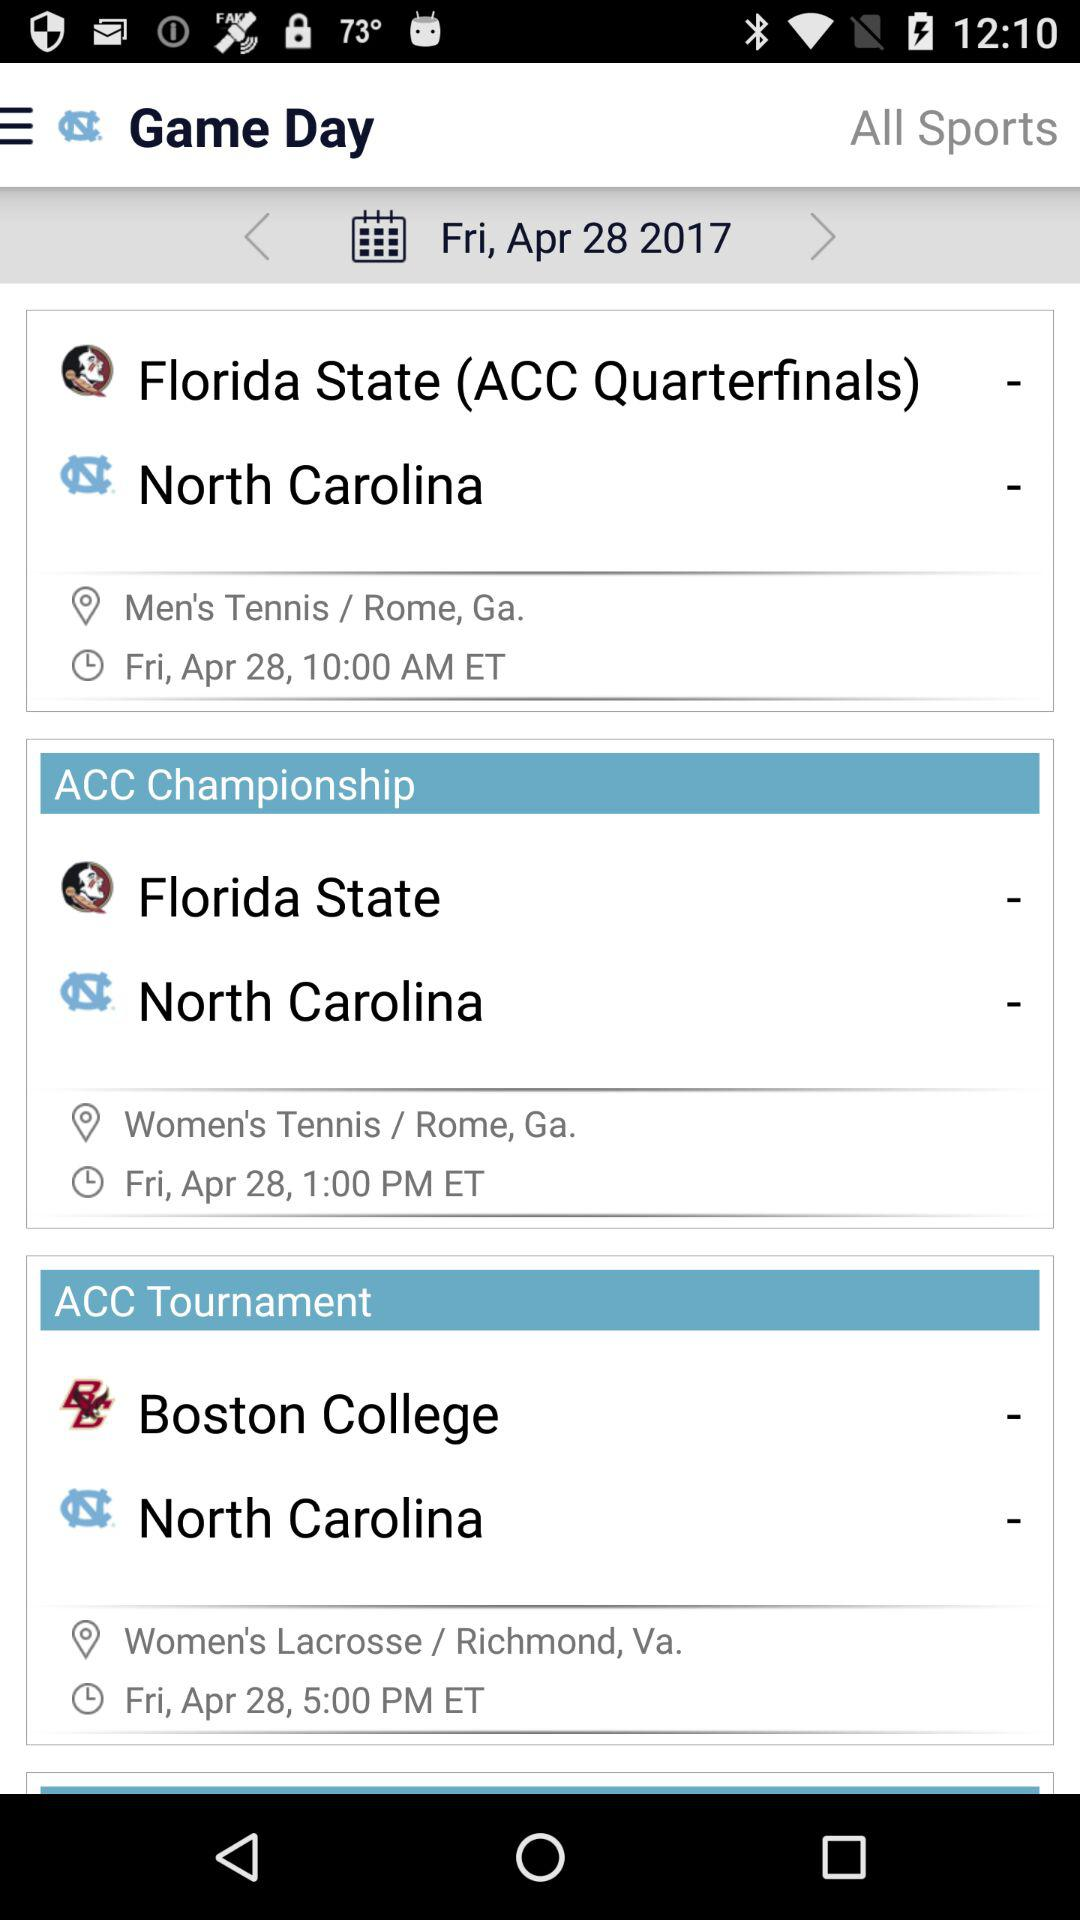

Preview judge: gpt5_2
Preview source: /home/mkhalil/thesis/Project/code/results/critiques/matching/gpt5/zero_shot-all_tasks/llmjudge_matching/gpt5_2/Batch_Requests/requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_1.jsonl


In [16]:
LLMJUDGE_PREVIEW_JUDGE = next(iter(llmjudge_run_configs))
LLMJUDGE_PREVIEW_INDEX = 0

preview_manager = globals().get("llmjudge_batch_managers", {}).get(LLMJUDGE_PREVIEW_JUDGE) or build_llmjudge_batch_manager(
    llmjudge_run_configs[LLMJUDGE_PREVIEW_JUDGE]
)
preview = preview_manager.preview_request(index=LLMJUDGE_PREVIEW_INDEX, display=True)
print("Preview judge:", LLMJUDGE_PREVIEW_JUDGE)
print("Preview source:", preview["source_file"])


### 4.5 Submit And Retrieve OpenAI LLMJudge Batches


In [11]:
def run_llmjudge_batches_for_provider(
    provider: str,
    *,
    run_batches: bool = True,
    batch_mode: str = "parallel",
    start_from_batch: int = 1,
    sleep_minutes: int = 2,
) -> None:
    llmjudge_batch_managers = globals().setdefault("llmjudge_batch_managers", {})
    llmjudge_batch_jobs = globals().setdefault("llmjudge_batch_jobs", {})

    judge_keys = [
        judge_model_short
        for judge_model_short, cfg in llmjudge_run_configs.items()
        if cfg["provider"] == provider
    ]
    if len(judge_keys) != 1:
        raise ValueError(f"Expected one {provider} LLMJudge config, found: {judge_keys}")

    judge_model_short = judge_keys[0]
    cfg = llmjudge_run_configs[judge_model_short]

    if not run_batches:
        print(f"{provider.title()} batch submission disabled. Set run_batches=True to submit/retrieve.")
        return

    print(f"\n{judge_model_short} {provider.title()} batch processing")
    client, _ = setup_client(
        cfg["provider"],
        model=cfg["judge_model"],
        model_short=cfg["judge_model_short"],
        system_message=DEFAULT_MATCH_REVIEW_SYSTEM_PROMPT,
        temperature=LLMJUDGE_TEMPERATURE,
        max_tokens=LLMJUDGE_MAX_TOKENS,
    )
    manager = build_llmjudge_batch_manager(cfg, client=client)
    llmjudge_batch_managers[judge_model_short] = manager

    if batch_mode == "parallel":
        llmjudge_batch_jobs[judge_model_short] = manager.process_batches_in_parallel(
            start_from_batch=start_from_batch,
            sleep_minutes=sleep_minutes,
        )
    elif batch_mode == "sequential":
        llmjudge_batch_jobs[judge_model_short] = manager.process_batches_sequentially(
            start_from_batch=start_from_batch,
            sleep_minutes=sleep_minutes,
        )
    else:
        raise ValueError(f"Unknown batch_mode: {batch_mode}")

#### 4.5a Submit And Retrieve OpenAI LLMJudge Batches

In [12]:
run_llmjudge_batches_for_provider(
    "openai",
    run_batches=True,
    batch_mode="parallel",
    start_from_batch=1,
    sleep_minutes=2,
)


gpt5_2 Openai batch processing
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_1.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_2.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_3.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_4.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_5.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_6.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_7.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_8.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_9.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_10.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_11.jsonl
Already retrieved: requests-human_llm_match_zero_shot

#### 4.5b Submit And Retrieve Gemini LLMJudge Batches

In [13]:
run_llmjudge_batches_for_provider(
    "gemini",
    run_batches=True,
    batch_mode="parallel",
    start_from_batch=1,
    sleep_minutes=2,
)


gemini_3_7_flash Gemini batch processing
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_1.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_2.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_3.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_4.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_5.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_6.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_7.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_8.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_9.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_10.jsonl
Already retrieved: requests-human_llm_match_zero_shot-all_tasks-gpt5-batch_11.jsonl
Already retrieved: requests-human_llm_match

### 4.6 Check Existing Batch Status


In [11]:
LLMJUDGE_BATCH_STATUS_LIMIT = 31

for judge_model_short, cfg in llmjudge_run_configs.items():
    print(f"\n{judge_model_short} provider batches")
    try:
        client, _ = setup_client(
            cfg["provider"],
            model=cfg["judge_model"],
            model_short=cfg["judge_model_short"],
            system_message=DEFAULT_MATCH_REVIEW_SYSTEM_PROMPT,
            temperature=LLMJUDGE_TEMPERATURE,
            max_tokens=LLMJUDGE_MAX_TOKENS,
        )
        manager = build_llmjudge_batch_manager(cfg, client=client)
        llmjudge_batch_managers[judge_model_short] = manager

        try:
            manager.list_batches(limit=LLMJUDGE_BATCH_STATUS_LIMIT)
        except TypeError:
            manager.list_batches()

        manifest_path = manager.root / f"batch_jobs-{LLMJUDGE_REVIEW_STEM}.json"
        if manifest_path.exists():
            print(f"Manifest: {manifest_path}")
            display(pd.read_json(manifest_path))
    except Exception as exc:
        print(f"Could not check {judge_model_short}: {type(exc).__name__}: {exc}")



gpt5_2 provider batches
Could not check gpt5_2: NameError: name 'llmjudge_batch_managers' is not defined

gemini_3_7_flash provider batches
Could not check gemini_3_7_flash: NameError: name 'llmjudge_batch_managers' is not defined


### 4.7 Inspect LLMJudge Batch Responses


In [ ]:
for judge_model_short, cfg in llmjudge_run_configs.items():
    manager = globals().get("llmjudge_batch_managers", {}).get(judge_model_short) or build_llmjudge_batch_manager(cfg)
    response_pattern = f"responses-{LLMJUDGE_REVIEW_STEM}-batch_*.jsonl"
    split_response_paths = sorted(manager.responses_dir.glob(response_pattern))

    print(f"{judge_model_short} ({cfg['provider']}): found {len(split_response_paths):,} response batch file(s).")


### 4.8 Locate LLMJudge Outputs


In [41]:
llmjudge_output_paths = {}

for judge_model_short, cfg in llmjudge_run_configs.items():
    manager = globals().get("llmjudge_batch_managers", {}).get(judge_model_short) or build_llmjudge_batch_manager(cfg)
    response_pattern = f"responses-{LLMJUDGE_REVIEW_STEM}-batch_*.jsonl"
    output_paths = sorted(manager.responses_dir.glob(response_pattern))
    if output_paths:
        llmjudge_output_paths[judge_model_short] = output_paths
        print(f"Using {len(output_paths)} LLMJudge batch response file(s) for {judge_model_short}: {manager.responses_dir}")
    else:
        print(f"No LLMJudge batch responses for {judge_model_short}. Expected pattern: {manager.responses_dir / response_pattern}")

print("Available LLMJudge outputs:", len(llmjudge_output_paths))


Using 31 LLMJudge batch response file(s) for gpt5_2: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gpt5_2/Batch_Responses
Using 31 LLMJudge batch response file(s) for gemini_3_7_flash: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/gemini_3_7_flash/Batch_Responses
Available LLMJudge outputs: 2


### 4.9 Load And Compare LLMJudge Responses


In [42]:
if len(llmjudge_output_paths) < 2:
    print("Need two saved LLMJudge output files before comparing judges.")
else:
    llmjudge_result_frames = []
    llmjudge_parse_audit_rows = []
    loaded_judge_keys = []

    for judge_model_short, output_paths in llmjudge_output_paths.items():
        judge_df = parse_llm_review_results_jsonl(
            output_paths,
            pairs_df,
            left_id_col="expert_comment_id",
            right_id_col="llm_comment_id",
            include_candidate_columns=[
                "pair_id",
                "screen_task_id",
                "task",
                "expert_comment_id",
                "llm_comment_id",
            ],
        )
        judge_df.insert(0, "judge_model_short", judge_model_short)
        judge_df.insert(1, "review_results_path", ";".join(str(path) for path in output_paths))
        llmjudge_result_frames.append(judge_df)
        loaded_judge_keys.append(judge_model_short)
        llmjudge_parse_audit_rows.append({
            "judge_model_short": judge_model_short,
            "results_path": ";".join(str(path) for path in output_paths),
            **audit_match_review_result_frame(judge_df, expected_llmjudge_pair_ids),
        })

    llmjudge_parse_audit_df = pd.DataFrame(llmjudge_parse_audit_rows)
    display(llmjudge_parse_audit_df)

    bad_audit_mask = match_review_audit_has_issues(llmjudge_parse_audit_df)
    if bad_audit_mask.any():
        raise ValueError("LLMJudge parse audit failed. Inspect llmjudge_parse_audit_df before comparing judges.")

    llmjudge_all_results_df = pd.concat(llmjudge_result_frames, ignore_index=True)
    left_judge, right_judge = loaded_judge_keys[:2]
    llmjudge_comparison_df = compare_match_review_judges(
        llmjudge_all_results_df,
        left_judge=left_judge,
        right_judge=right_judge,
    )
    disagreement_mask = ~llmjudge_comparison_df["same_relation"].fillna(False)

    print("Compared judges:", left_judge, "vs", right_judge)
    print("Rows compared:", len(llmjudge_comparison_df))
    print("Merge status:")
    print(llmjudge_comparison_df["_merge"].value_counts().to_string())
    both_rows = llmjudge_comparison_df[llmjudge_comparison_df["_merge"].eq("both")]
    print("Same relation rate:", both_rows["same_relation"].mean())
    print("Disagreement rows:", int(disagreement_mask.sum()))

    display(pd.crosstab(
        llmjudge_comparison_df[f"relation__{left_judge}"],
        llmjudge_comparison_df[f"relation__{right_judge}"],
        dropna=False,
    ))

,judge_model_short,results_path,parsed_rows,expected_pairs,missing_pair_ids,extra_pair_ids,duplicate_pair_ids,invalid_relations,missing_diagnostic_values,invalid_diagnostic_values,missing_identity_rows,missing_parse_columns,missing_examples,extra_examples,duplicate_examples,invalid_relation_examples
0,gpt5_2,/home/mkhalil/thesis/Project/code/results/crit...,36015,36015,0,0,0,0,0,0,0,[],[],[],[],[]
1,gemini_3_7_flash,/home/mkhalil/thesis/Project/code/results/crit...,36015,36015,0,0,0,0,0,0,0,[],[],[],[],[]


Compared judges: gpt5_2 vs gemini_3_7_flash
Rows compared: 36015
Merge status:
_merge
both          36015
left_only         0
right_only        0
Same relation rate: 0.7448840760794113
Disagreement rows: 9188


relation__gemini_3_7_flash,A_broader,B_broader,contradiction,equivalent,no_match,partial_overlap,related_but_different
relation__gpt5_2,,,,,,,
A_broader,152,41,4,145,66,58,516
B_broader,20,351,0,160,86,16,299
contradiction,0,0,11,3,19,0,18
equivalent,8,50,0,620,12,3,63
no_match,2,12,7,8,20104,1,3457
partial_overlap,26,72,4,117,256,93,1244
related_but_different,4,78,21,78,2198,16,5496


Check Errors

In [43]:
if "llmjudge_parse_audit_df" not in globals():
    raise NameError("Run section 8.9 first. If it fails, this cell can inspect the partial audit.")

error_audit_df = llmjudge_parse_audit_df[match_review_audit_has_issues(llmjudge_parse_audit_df)].copy()

if error_audit_df.empty:
    print("No LLMJudge audit errors.")
else:
    display(error_audit_df)

    # Optional: set to one audit column to show only that issue.
    SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN = ""

    if SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN:
        if SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN not in llmjudge_parse_audit_df.columns:
            raise ValueError(f"Unknown audit column: {SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN}")

        selected_values = llmjudge_parse_audit_df[SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN]
        if selected_values.map(lambda value: isinstance(value, list)).any():
            selected_mask = selected_values.map(len).gt(0)
        else:
            selected_mask = pd.to_numeric(selected_values, errors="coerce").fillna(0).gt(0)

        display_cols = ["judge_model_short", SELECTED_LLMJUDGE_AUDIT_ERROR_COLUMN]
        display(llmjudge_parse_audit_df.loc[selected_mask, display_cols])


No LLMJudge audit errors.


### 4.9.1 Summarize LLMJudge Disagreements


In [44]:
if "llmjudge_comparison_df" not in globals():
    raise NameError("Run section 8.9 first so llmjudge_comparison_df is available.")

left_relation_col = f"relation__{left_judge}"
right_relation_col = f"relation__{right_judge}"
left_confidence_col = f"confidence__{left_judge}"
right_confidence_col = f"confidence__{right_judge}"

def relation_pair_counts(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame(columns=["relation_pair", "n"])
    relation_pairs = df[[left_relation_col, right_relation_col]].astype(str)
    relation_pair_labels = (
        relation_pairs.min(axis=1) + " | " + relation_pairs.max(axis=1)
    )
    return (
        relation_pair_labels
        .value_counts()
        .rename_axis("relation_pair")
        .reset_index(name="n")
    )


disagreement_mask = ~llmjudge_comparison_df["same_relation"].fillna(False)
disagreement_pair_counts_df = relation_pair_counts(
    llmjudge_comparison_df.loc[disagreement_mask]
)
display(disagreement_pair_counts_df)


,relation_pair,n
0,no_match | related_but_different,5655
1,partial_overlap | related_but_different,1260
2,A_broader | related_but_different,520
3,B_broader | related_but_different,377
4,no_match | partial_overlap,257
5,B_broader | equivalent,210
6,A_broader | equivalent,153
7,equivalent | related_but_different,141
8,equivalent | partial_overlap,120
9,B_broader | no_match,98


### 4.10 Interactive Review Remaining LLMJudge Disagreements


In [45]:
if "llmjudge_comparison_df" not in globals():
    raise NameError("Run section 8.9 first so llmjudge_comparison_df is available.")
# Set to a value from disagreement_pair_counts_df["relation_pair"], e.g. "equivalent | no_match".
# Use None to review all remaining disagreement relation pairs.
SELECTED_MANUAL_RELATION_PAIR = "A_broader | contradiction"
MANUAL_REVIEW_BATCH_SIZE = 50
DISPLAY_SCREEN_IN_MANUAL_REVIEW = True
MANUAL_REVIEW_SCREEN_WIDTH = 300

LLMJUDGE_MANUAL_OVERRIDES_PATH = llmjudge_dir / f"llmjudge_manual_relation_overrides-{OUTPUT_STEM}.csv"

if "manual_relation_overrides" not in globals():
    manual_relation_overrides = {}
if "manual_confidence_overrides" not in globals():
    manual_confidence_overrides = {}

if LLMJUDGE_MANUAL_OVERRIDES_PATH.exists():
    saved_manual_overrides_df = pd.read_csv(LLMJUDGE_MANUAL_OVERRIDES_PATH)
    if len(saved_manual_overrides_df):
        manual_relation_overrides.update(
            saved_manual_overrides_df.set_index("pair_id")["manual_relation"].dropna().to_dict()
        )
        manual_confidence_overrides.update(
            saved_manual_overrides_df.set_index("pair_id")["manual_confidence"].dropna().astype(float).to_dict()
        )
        print(f"Loaded saved manual overrides: {len(saved_manual_overrides_df):,}")

RELATION_SHORTCUTS = {
    "e": "equivalent",
    "a": "A_broader",
    "b": "B_broader",
    "p": "partial_overlap",
    "r": "related_but_different",
    "n": "no_match",
    "c": "contradiction",
}


def relation_pair_label(df: pd.DataFrame) -> pd.Series:
    relation_pairs = df[[left_relation_col, right_relation_col]].astype(str)
    return relation_pairs.min(axis=1) + " | " + relation_pairs.max(axis=1)


def has_value(value: object) -> bool:
    if value is None:
        return False
    try:
        is_missing = pd.isna(value)
    except (TypeError, ValueError):
        return True
    if isinstance(is_missing, (bool, np.bool_)):
        return not bool(is_missing)
    return True


def print_pair_line(label: str, left_value: object, right_value: object, *, width: int = 36) -> None:
    left_text = "" if not has_value(left_value) else str(left_value)
    right_text = "" if not has_value(right_value) else str(right_value)
    print(f"{label:<44} | {left_text:<{width}.{width}} | {right_text:<{width}.{width}}")


def display_manual_review_screen(row: pd.Series) -> None:
    if not DISPLAY_SCREEN_IN_MANUAL_REVIEW:
        return
    screen_id = row.get("screen_id") if "screen_id" in row.index else None
    base64_screen = row.get("base64_screen") if "base64_screen" in row.index else None
    if not has_value(screen_id) and not has_value(base64_screen):
        print("screen display unavailable: no screen_id/base64_screen on row")
        return

    bboxes = []
    labels = []
    for bbox_col, label in (("expert_bounding_box", "expert"), ("llm_bounding_box", "llm")):
        bbox = row.get(bbox_col) if bbox_col in row.index else None
        if has_value(bbox):
            bboxes.append(bbox)
            labels.append(label)

    try:
        from utils.screen_display import show_screen

        show_screen(
            screen_id=screen_id if has_value(screen_id) else None,
            base64_screen=str(base64_screen) if has_value(base64_screen) else None,
            bboxes=bboxes,
            labels=labels,
            width=MANUAL_REVIEW_SCREEN_WIDTH,
        )
    except Exception as exc:
        print(f"screen display unavailable: {exc}")


review_context_cols = [
    "screen_id",
    "base64_screen",
    "task",
    "expert_observed_issue",
    "llm_observed_issue",
    "expert_bounding_box",
    "llm_bounding_box",
]
latest_remaining_df = (
    finalize_match_review_judges(
        llmjudge_comparison_df,
        left_judge=left_judge,
        right_judge=right_judge,
        manual_relation_overrides=manual_relation_overrides,
        manual_confidence_overrides=manual_confidence_overrides,
    )
    .loc[lambda df: df["decision_source"].eq("manual_review")]
    .copy()
)
latest_remaining_df["relation_pair"] = relation_pair_label(latest_remaining_df)

latest_missing_context_cols = [
    col for col in review_context_cols
    if col not in latest_remaining_df.columns and col in pairs_df.columns
]
if latest_missing_context_cols:
    latest_remaining_df = latest_remaining_df.merge(
        pairs_df[["pair_id", *latest_missing_context_cols]].drop_duplicates("pair_id"),
        on="pair_id",
        how="left",
        validate="one_to_one",
    )

if SELECTED_MANUAL_RELATION_PAIR is not None:
    manual_review_queue_df = latest_remaining_df[
        latest_remaining_df["relation_pair"].eq(SELECTED_MANUAL_RELATION_PAIR)
    ].copy()
else:
    manual_review_queue_df = latest_remaining_df.copy()

if MANUAL_REVIEW_BATCH_SIZE is not None:
    manual_review_queue_df = manual_review_queue_df.head(MANUAL_REVIEW_BATCH_SIZE)

print(f"Selected relation_pair: {SELECTED_MANUAL_RELATION_PAIR or 'ALL'}")
print(f"Manual overrides already available: {len(manual_relation_overrides):,}")
print(f"Remaining disagreements overall: {len(latest_remaining_df):,}")
print(f"Rows queued in this interactive pass: {len(manual_review_queue_df):,}")
print("Commands: e=equivalent, a=A_broader, b=B_broader, p=partial_overlap, r=related_but_different, n=no_match, c=contradiction, s=skip, q=quit")

for i, row in manual_review_queue_df.reset_index(drop=True).iterrows():
    pair_id = row["pair_id"]
    print("\n" + "=" * 118)
    print(f"{i + 1}/{len(manual_review_queue_df)} | {pair_id} | relation_pair={row.get('relation_pair')}")
    print("screen_task_id:", row.get("screen_task_id"))
    print("screen_id:", row.get("screen_id"))
    print("task:", row.get("task"))
    print("expert_comment_id:", row.get("expert_comment_id"))
    print("llm_comment_id:", row.get("llm_comment_id"))
    print("-" * 118)
    print(f"{'field':<44} | {left_judge:<36.36} | {right_judge:<36.36}")
    print(f"{'-' * 44} | {'-' * 36} | {'-' * 36}")
    print_pair_line("relation", row.get(left_relation_col), row.get(right_relation_col))
    print_pair_line("confidence", row.get(left_confidence_col), row.get(right_confidence_col))
    for diagnostic_col in MATCH_REVIEW_DIAGNOSTIC_COLUMNS:
        print_pair_line(
            diagnostic_col,
            row.get(f"{diagnostic_col}__{left_judge}"),
            row.get(f"{diagnostic_col}__{right_judge}"),
        )
    print("-" * 118)
    print("EXPERT:", row.get("expert_observed_issue"))
    print("LLM   :", row.get("llm_observed_issue"))
    display_manual_review_screen(row)

    cmd = input("relation: ").strip().lower()
    if cmd == "q":
        break
    if cmd in {"", "s"}:
        continue
    if cmd not in RELATION_SHORTCUTS:
        print("Invalid choice; skipping.")
        continue

    manual_relation_overrides[pair_id] = RELATION_SHORTCUTS[cmd]
    manual_confidence_overrides[pair_id] = 1.0

    pd.DataFrame([
        {
            "pair_id": pair_id,
            "manual_relation": relation,
            "manual_confidence": manual_confidence_overrides[pair_id],
        }
        for pair_id, relation in manual_relation_overrides.items()
    ]).sort_values("pair_id").to_csv(LLMJUDGE_MANUAL_OVERRIDES_PATH, index=False)

llmjudge_final_df = finalize_match_review_judges(
    llmjudge_comparison_df,
    left_judge=left_judge,
    right_judge=right_judge,
    manual_relation_overrides=manual_relation_overrides,
    manual_confidence_overrides=manual_confidence_overrides,
)
remaining_manual_mask = llmjudge_final_df["decision_source"].eq("manual_review")

print("\nDecision source counts:")
print(llmjudge_final_df["decision_source"].value_counts().sort_index().to_string())
print("Unresolved disagreements:", int(remaining_manual_mask.sum()))
print(f"Saved manual overrides to: {LLMJUDGE_MANUAL_OVERRIDES_PATH}")

if remaining_manual_mask.any():
    remaining_relation_pair_counts_df = (
        relation_pair_label(llmjudge_final_df.loc[remaining_manual_mask])
        .value_counts()
        .rename_axis("relation_pair")
        .reset_index(name="n")
    )
    display(remaining_relation_pair_counts_df)


Loaded saved manual overrides: 102
Selected relation_pair: A_broader | contradiction
Manual overrides already available: 406
Remaining disagreements overall: 9,036
Rows queued in this interactive pass: 0
Commands: e=equivalent, a=A_broader, b=B_broader, p=partial_overlap, r=related_but_different, n=no_match, c=contradiction, s=skip, q=quit

Decision source counts:
decision_source
judge_agreement    26827
manual_override      152
manual_review       9036
Unresolved disagreements: 9036
Saved manual overrides to: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/llmjudge_manual_relation_overrides-zero_shot-all_tasks-gemini3_1pro.csv


,relation_pair,n
0,no_match | related_but_different,5623
1,partial_overlap | related_but_different,1256
2,A_broader | related_but_different,518
3,B_broader | related_but_different,376
4,no_match | partial_overlap,254
5,B_broader | equivalent,209
6,A_broader | equivalent,153
7,equivalent | related_but_different,140
8,equivalent | partial_overlap,120
9,B_broader | no_match,97


### 4.11 Explore Relations


In [46]:
if "llmjudge_final_df" in globals():
    relation_source = llmjudge_final_df

relation_counts_df = (
    relation_source["relation"]
    .value_counts(dropna=False)
    .rename_axis("relation")
    .reset_index(name="pairs")
)
confidence_summary_df = relation_source["confidence"].describe().to_frame("confidence")

display(relation_counts_df)
display(confidence_summary_df)


,relation,pairs
0,no_match,20195
1,NaN,9036
2,related_but_different,5511
3,equivalent,643
4,B_broader,353
5,A_broader,155
6,partial_overlap,104
7,contradiction,18


,confidence
count,26979.000000
mean,0.805698
std,0.058755
min,0.635000
25%,0.765000
50%,0.805000
75%,0.840000
max,1.000000


### 4.11.1 Auto-Resolve Remaining Disagreements


In [47]:
if "llmjudge_comparison_df" not in globals():
    raise NameError("Run section 8.9 first so llmjudge_comparison_df is available.")
AUTO_RESOLVE_STRATEGY = "higher_confidence"  # "weaker_coverage" | "higher_confidence" | "none"
RELATION_FALLBACK_ORDER = [
    "contradiction",
    "no_match",
    "related_but_different",
    "partial_overlap",
    "equivalent",
    "A_broader",
    "B_broader",
]
RELATION_FALLBACK_RANK = {relation: i for i, relation in enumerate(RELATION_FALLBACK_ORDER)}

LLMJUDGE_MANUAL_OVERRIDES_PATH = llmjudge_dir / f"llmjudge_manual_relation_overrides-{OUTPUT_STEM}.csv"
manual_relation_overrides = globals().get("manual_relation_overrides", {}).copy()
manual_confidence_overrides = globals().get("manual_confidence_overrides", {}).copy()

if LLMJUDGE_MANUAL_OVERRIDES_PATH.exists():
    saved_manual_overrides_df = pd.read_csv(LLMJUDGE_MANUAL_OVERRIDES_PATH)
    manual_relation_overrides.update(
        saved_manual_overrides_df.set_index("pair_id")["manual_relation"].dropna().to_dict()
    )
    manual_confidence_overrides.update(
        saved_manual_overrides_df.set_index("pair_id")["manual_confidence"].dropna().astype(float).to_dict()
    )
    print(f"Loaded saved manual overrides: {len(saved_manual_overrides_df):,}")

llmjudge_final_df = finalize_match_review_judges(
    llmjudge_comparison_df,
    left_judge=left_judge,
    right_judge=right_judge,
    manual_relation_overrides=manual_relation_overrides,
    manual_confidence_overrides=manual_confidence_overrides,
)

left_relation_col = f"relation__{left_judge}"
right_relation_col = f"relation__{right_judge}"
left_confidence_col = f"confidence__{left_judge}"
right_confidence_col = f"confidence__{right_judge}"
remaining_mask = llmjudge_final_df["decision_source"].eq("manual_review")
remaining_before = int(remaining_mask.sum())

if AUTO_RESOLVE_STRATEGY != "none" and remaining_before:
    unresolved = llmjudge_final_df.loc[remaining_mask]
    left_confidence = unresolved[left_confidence_col].fillna(-1).astype(float)
    right_confidence = unresolved[right_confidence_col].fillna(-1).astype(float)
    left_rank = unresolved[left_relation_col].map(RELATION_FALLBACK_RANK).fillna(999)
    right_rank = unresolved[right_relation_col].map(RELATION_FALLBACK_RANK).fillna(999)

    if AUTO_RESOLVE_STRATEGY == "weaker_coverage":
        choose_left = left_rank <= right_rank
    elif AUTO_RESOLVE_STRATEGY == "higher_confidence":
        choose_left = (left_confidence > right_confidence) | (
            left_confidence.eq(right_confidence) & (left_rank <= right_rank)
        )
    else:
        raise ValueError(f"Unsupported AUTO_RESOLVE_STRATEGY: {AUTO_RESOLVE_STRATEGY}")

    llmjudge_final_df.loc[remaining_mask, "relation"] = unresolved[left_relation_col].where(
        choose_left,
        unresolved[right_relation_col],
    ).values
    llmjudge_final_df.loc[remaining_mask, "confidence"] = left_confidence.where(
        choose_left,
        right_confidence,
    ).values
    llmjudge_final_df.loc[remaining_mask, "final_relation"] = llmjudge_final_df.loc[remaining_mask, "relation"]
    llmjudge_final_df.loc[remaining_mask, "final_confidence"] = llmjudge_final_df.loc[remaining_mask, "confidence"]
    llmjudge_final_df.loc[remaining_mask, "decision_source"] = f"auto_{AUTO_RESOLVE_STRATEGY}_fallback"

relation_source = llmjudge_final_df
relation_counts_df = (
    relation_source["relation"]
    .value_counts(dropna=False)
    .rename_axis("relation")
    .reset_index(name="pairs")
)

print(f"AUTO_RESOLVE_STRATEGY: {AUTO_RESOLVE_STRATEGY}")
print(f"Remaining manual_review before fallback: {remaining_before:,}")
print("Decision source counts after fallback:")
print(llmjudge_final_df["decision_source"].value_counts().sort_index().to_string())
print("Unresolved disagreements after fallback:", int(llmjudge_final_df["decision_source"].eq("manual_review").sum()))
print("Missing final relations:", int(llmjudge_final_df["relation"].isna().sum()))
display(relation_counts_df)

if AUTO_RESOLVE_STRATEGY != "none" and llmjudge_final_df["relation"].isna().any():
    raise ValueError("Fallback resolution left missing relation values. Inspect llmjudge_final_df before saving.")


Loaded saved manual overrides: 102
AUTO_RESOLVE_STRATEGY: higher_confidence
Remaining manual_review before fallback: 9,036
Decision source counts after fallback:
decision_source
auto_higher_confidence_fallback     9036
judge_agreement                    26827
manual_override                      152
Unresolved disagreements after fallback: 0
Missing final relations: 0


,relation,pairs
0,no_match,25154
1,related_but_different,8475
2,equivalent,1141
3,B_broader,658
4,A_broader,315
5,partial_overlap,254
6,contradiction,18


### 4.12 Save LLMJudge Matching Outputs

```text
llmjudge_matching_pairs-{run_label}-{llm_name}.parquet
```

Final rows stay pair-level and include both judge labels/confidences plus the resolved relation, confidence, and decision source.


In [48]:
if "llmjudge_final_df" not in globals():
    raise NameError("Run sections 8.9-8.11.1 before saving LLMJudge matching outputs.")
if llmjudge_final_df["decision_source"].eq("manual_review").any():
    raise ValueError("Resolve all LLMJudge disagreements before saving final matching pairs.")

judge_decision_cols = [
    "pair_id",
    "custom_id",
    f"relation__{left_judge}",
    f"confidence__{left_judge}",
    f"relation__{right_judge}",
    f"confidence__{right_judge}",
    "manual_relation",
    "manual_confidence",
    *MATCH_REVIEW_DIAGNOSTIC_COLUMNS,
    *[f"{col}__{left_judge}" for col in MATCH_REVIEW_DIAGNOSTIC_COLUMNS],
    *[f"{col}__{right_judge}" for col in MATCH_REVIEW_DIAGNOSTIC_COLUMNS],
    "relation",
    "confidence",
    "decision_source",
]

matching_pairs_df = select_basic_pair_columns(pairs_df).merge(
    llmjudge_final_df[judge_decision_cols],
    on="pair_id",
    how="left",
    validate="one_to_one",
)
if matching_pairs_df["decision_source"].isna().any():
    missing_pairs = matching_pairs_df.loc[matching_pairs_df["decision_source"].isna(), "pair_id"].head(10).tolist()
    raise ValueError(f"Missing finalized LLMJudge decisions for pair_ids: {missing_pairs}")

matching_pairs_df.to_parquet(LLMJUDGE_MATCHING_PAIRS_PATH, index=False)

print(f"Matching pair rows: {len(matching_pairs_df):,}")
print(f"Saved matching pairs to: {LLMJUDGE_MATCHING_PAIRS_PATH}")
matching_pairs_df.head(1)

Matching pair rows: 36,015
Saved matching pairs to: /home/mkhalil/thesis/Project/code/results/critiques/matching/gemini3_1pro/zero_shot-all_tasks/llmjudge_matching/llmjudge_matching_pairs-zero_shot-all_tasks-gemini3_1pro.parquet


,pair_id,screen_task_id,expert_comment_id,expert_comment_source,expert_observed_issue,llm_comment_id,llm_observed_issue,custom_id,relation__gpt5_2,confidence__gpt5_2,...,comment_b_depends_on_unseen_interaction__gpt5_2,logical_conflict__gpt5_2,same_target_element__gemini_3_7_flash,same_usability_problem__gemini_3_7_flash,comment_a_depends_on_unseen_interaction__gemini_3_7_flash,comment_b_depends_on_unseen_interaction__gemini_3_7_flash,logical_conflict__gemini_3_7_flash,relation,confidence,decision_source
0,P_00000001,10089_T01,10089_T01_002,LLM,the menu icon is extending beyond the screen e...,L_gemini3_1pro_10089_T01_001,The light gray arrow icons lack sufficient con...,P_00000001::10089_T01_002::L_gemini3_1pro_1008...,no_match,0.9,...,no,no,no,no,no,no,no,no_match,0.85,judge_agreement
